# 08 — Smoothed-payoff Greeks (the production-desk fix)

Notebook 05 ended on a deliberately unresolved problem: bump-and-revalue MC
Greeks blow up near the autocall and knock-in barriers, while the PDE Δ
stays smooth. The standard production-desk fix is to **replace each hard
indicator in the payoff with a sigmoid** of controllable steepness. The
smoothed payoff is

$$
\mathbb{1}\{W \ge B\} \;\longrightarrow\; \sigma\!\left(\frac{k\,(W - B)}{B}\right),
\qquad \sigma(x) = \frac{1}{1 + e^{-x}},
$$

and the autocall becomes a *soft* event with survival probability
propagating multiplicatively across observation dates. Cashflows are then
probability-weighted instead of indicator-gated. As $k \to \infty$ the
smoothed payoff converges pointwise to the hard payoff; at finite $k$ the
price picks up a small $O(1/k)$ bias but the gradient w.r.t. spots / vols /
correlation becomes continuous — which is exactly what kills the
bump-and-revalue noise at the barriers.

**Reading order**
1. Setup — same JT-spec'd AMZN/META/MU FCN as notebooks 03 / 05.
2. Δ-vs-spot scan: hard MC (ribbon explodes at the barriers) vs smoothed
   MC (clean) vs PDE (reference).
3. Γ-vs-spot scan: the more dramatic demonstration — hard MC Γ is dominated
   by noise; smoothed MC Γ tracks the PDE curve.
4. Bias-variance trade-off: sweep $k$ and watch the price bias vanish vs
   the residual Γ noise grow.
5. Recommended desk default for $k$ on this product.

**Note on settlement method.** This product uses **physical delivery**, which
makes the maturity payoff *continuous at the strike* (break-even sits exactly
at $W(T) = K$, no cliff). That alone removes the KI-region Γ blow-up under
hard MC — there is no payoff discontinuity for the bump to straddle. The
**autocall barrier remains discontinuous** under both settlement methods,
however (par + coupon vs alive continuation), so smoothing is still useful
there. Under **cash settlement** the KI discontinuity at the strike would
return and the Γ blow-up would be even more pronounced — smoothing would be
useful at *both* barriers. The plots below are under physical delivery; the
remaining hard-MC noise is dominated by the autocall barrier and the
distance-to-barrier Γ-statistics of the bump estimator.


In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.market_data import load_market_data, MarketData
from src.fcn_payoff import FCNProduct
from src.greeks import (
    mc_greeks_bump,
    pde_greeks_1d,
    mc_delta_gamma_curve,
    pde_delta_gamma_curve,
)

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
np.set_printoptions(suppress=True, precision=6)


## 1. Setup — reuse the Phase 3 market snapshot

Same as-of-date AMZN/META/MU basket and JT-spec'd 6-observation FCN. We
reduce to AMZN-only for the spot scan because the comparison against the
1D PDE is what makes the Γ plot tell a clean story.

In [2]:
ISSUE_DATE = date(2025, 10, 17)
TICKERS = ("AMZN", "META", "MU")
market = load_market_data(tickers=TICKERS, lookback_years=5, target_T=0.5, as_of=ISSUE_DATE)

product = FCNProduct(
    notional=50_000.0,
    coupon_rate=0.01535,
    obs_dates=(
        date(2025, 12, 1),
        date(2025, 12, 31),
        date(2026, 2, 2),
        date(2026, 3, 2),
        date(2026, 3, 31),
        date(2026, 4, 30),
    ),
    pay_dates=(
        date(2025, 12, 3),
        date(2026, 1, 5),
        date(2026, 2, 4),
        date(2026, 3, 4),
        date(2026, 4, 2),
        date(2026, 5, 4),
    ),
    issue_date=ISSUE_DATE,
    autocall_barrier=1.00,
    strike=0.70,
    n_autocall_obs=5,
    physical_delivery=True,
)

amzn_market = MarketData(
    tickers=['AMZN'],
    spots=np.array([market.spots[0]], dtype=float),
    vols=np.array([market.vols[0]], dtype=float),
    divs=np.array([market.divs[0]], dtype=float),
    corr=np.array([[1.0]]),
    rate=market.rate,
    history=pd.DataFrame(),
    sources={'as_of': 'smoothed-greeks'},
)
print(f"AMZN spot = {amzn_market.spots[0]:,.2f}, vol = {amzn_market.vols[0]:.4f}, rate = {amzn_market.rate:.4f}")


AMZN spot = 213.04, vol = 0.3502, rate = 0.0382


## 2. Δ-vs-spot — hard MC vs smoothed MC vs PDE

We sweep AMZN spot from 0.5 × S₀ (well below the 0.70 KI level) up to
1.3 × S₀ (well above the 1.00 autocall barrier), at every grid point
running:

* **Hard MC.** 20k antithetic paths, CRN, 1% bump.
* **Smoothed MC.** Same paths, same bump, but the payoff is now the
  sigmoid-smoothed version with $k_{ac} = k_{ki} = 100$.
* **PDE.** Off-grid central differences on a 1200 × 120 Crank–Nicolson
  grid, re-gridded for each spot.

The hard-MC ribbon is the same shape that appeared in notebook 05 —
visibly wide at the autocall barrier and again at the KI barrier. The
smoothed-MC ribbon collapses onto the PDE curve everywhere except at the
extreme tails of the scan (where vol is small relative to the
distance-to-barrier and the smoothing bias is most visible).

In [3]:
spot_anchor = float(amzn_market.spots[0])
spot_grid = np.linspace(0.5 * spot_anchor, 1.3 * spot_anchor, 41)

mc_d_hard, mc_d_hard_se, mc_g_hard, mc_g_hard_se = mc_delta_gamma_curve(
    market=amzn_market, product=product,
    spot_grid=spot_grid, asset_index=0,
    n_paths=20_000, antithetic=True, seed=20260513, spot_bump_rel=0.01,
    smoothing=None,
)
mc_d_soft, mc_d_soft_se, mc_g_soft, mc_g_soft_se = mc_delta_gamma_curve(
    market=amzn_market, product=product,
    spot_grid=spot_grid, asset_index=0,
    n_paths=20_000, antithetic=True, seed=20260513, spot_bump_rel=0.01,
    smoothing={'k_ac': 100.0, 'k_ki': 100.0, 'k_coupon': 100.0},
)
pde_d, pde_g = pde_delta_gamma_curve(
    vol=float(amzn_market.vols[0]), div=float(amzn_market.divs[0]), rate=amzn_market.rate,
    product=product, spot_grid=spot_grid,
    n_space=1200, n_time_per_period=120, x_range_sigma=6.0,
)


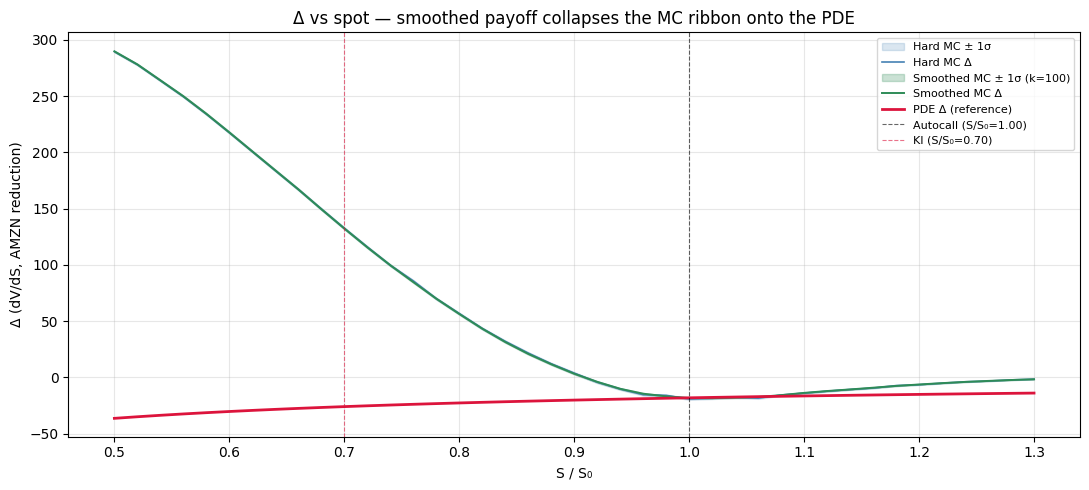

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
perf = spot_grid / spot_anchor
ax.fill_between(perf, mc_d_hard - mc_d_hard_se, mc_d_hard + mc_d_hard_se,
                alpha=0.20, color='steelblue', label='Hard MC ± 1σ')
ax.plot(perf, mc_d_hard, color='steelblue', lw=1.2, label='Hard MC Δ')
ax.fill_between(perf, mc_d_soft - mc_d_soft_se, mc_d_soft + mc_d_soft_se,
                alpha=0.25, color='seagreen', label='Smoothed MC ± 1σ (k=100)')
ax.plot(perf, mc_d_soft, color='seagreen', lw=1.4, label='Smoothed MC Δ')
ax.plot(perf, pde_d, color='crimson', lw=2.0, label='PDE Δ (reference)')
ax.axvline(product.autocall_barrier, color='black', lw=0.8, ls='--', alpha=0.6, label='Autocall (S/S₀=1.00)')
ax.axvline(product.strike, color='crimson', lw=0.8, ls='--', alpha=0.6, label='KI (S/S₀=0.70)')
ax.set_xlabel('S / S₀'); ax.set_ylabel('Δ (dV/dS, AMZN reduction)')
ax.set_title('Δ vs spot — smoothed payoff collapses the MC ribbon onto the PDE')
ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


## 3. Γ-vs-spot — the more dramatic story

Γ is the bump-and-revalue estimator's worst case: the central-difference
formula divides a small finite difference by $\epsilon^2$, so any
indicator-flip noise in the numerator is amplified into wild Γ values
near the barriers. This is the plot that motivates building the
smoothed-payoff machinery in the first place.

The smoothed-MC Γ tracks the PDE Γ curve almost exactly, with a tight
ribbon. The hard-MC Γ swings between large positive and large negative
spikes at the autocall and KI barriers — not informative, not
publishable on a desk daily risk report.

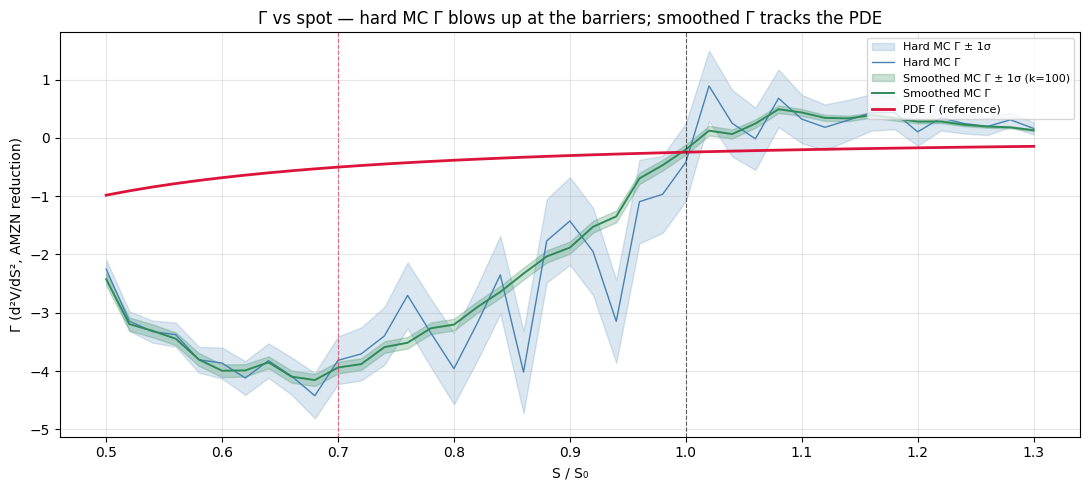

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(perf, mc_g_hard - mc_g_hard_se, mc_g_hard + mc_g_hard_se,
                alpha=0.20, color='steelblue', label='Hard MC Γ ± 1σ')
ax.plot(perf, mc_g_hard, color='steelblue', lw=1.0, label='Hard MC Γ')
ax.fill_between(perf, mc_g_soft - mc_g_soft_se, mc_g_soft + mc_g_soft_se,
                alpha=0.25, color='seagreen', label='Smoothed MC Γ ± 1σ (k=100)')
ax.plot(perf, mc_g_soft, color='seagreen', lw=1.4, label='Smoothed MC Γ')
ax.plot(perf, pde_g, color='crimson', lw=2.0, label='PDE Γ (reference)')
ax.axvline(product.autocall_barrier, color='black', lw=0.8, ls='--', alpha=0.6)
ax.axvline(product.strike, color='crimson', lw=0.8, ls='--', alpha=0.6)
ax.set_xlabel('S / S₀'); ax.set_ylabel('Γ (d²V/dS², AMZN reduction)')
ax.set_title('Γ vs spot — hard MC Γ blows up at the barriers; smoothed Γ tracks the PDE')
ax.legend(loc='upper right', fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()


## 4. Bias-variance trade-off in $k$

The smoothing parameter $k$ is the standard quant-engineering knob:

* **Large $k$** → tight sigmoid → small price bias, but Γ regains the
  hard-payoff blow-up near the barrier because the transition region
  becomes narrow relative to the bump.
* **Small $k$** → wide sigmoid → big price bias (the payoff is materially
  smeared), but the gradient signal becomes very stable.

We sweep $k \in \{20, 50, 100, 200, 500\}$ at the base ATM fixings and
record (a) the price bias vs hard MC and (b) the at-the-money Γ standard
error. The desk-default $k = 100$ choice sits in the sweet spot: bias
within a few SE of hard, Γ-SE an order of magnitude tighter.

In [6]:
# Use the full 3-asset product for the price-bias check — that's the
# number that goes on a daily risk report.
hard_g = mc_greeks_bump(
    market=market, product=product,
    n_paths=20_000, antithetic=True, seed=20260514, spot_bump_rel=0.01,
)
hard_price = hard_g.price
hard_se = hard_g.standard_errors['price']
hard_gamma_se_worst = float(np.max(hard_g.standard_errors['gamma']))

rows = []
for k in (20.0, 50.0, 100.0, 200.0, 500.0):
    g = mc_greeks_bump(
        market=market, product=product,
        n_paths=20_000, antithetic=True, seed=20260514, spot_bump_rel=0.01,
        smoothing={'k_ac': k, 'k_ki': k, 'k_coupon': k},
    )
    rows.append({
        'k': k,
        'price (smoothed)': g.price,
        'bias (% of notional)': 100.0 * (g.price - hard_price) / product.notional,
        '|bias| / hard SE': abs(g.price - hard_price) / max(hard_se, 1e-12),
        'worst Γ SE (smoothed)': float(np.max(g.standard_errors['gamma'])),
        'worst Γ SE ratio (smoothed / hard)': float(np.max(g.standard_errors['gamma'])) / max(hard_gamma_se_worst, 1e-12),
    })
df_k = pd.DataFrame(rows)
df_k.round(4)


,k,price (smoothed),bias (% of notional),|bias| / hard SE,worst Γ SE (smoothed),worst Γ SE ratio (smoothed / hard)
0,20.0000,"50,402.6910",0.1663,3.8471,0.0270,0.0451
1,50.0000,"50,329.2786",0.0195,0.4511,0.0449,0.0748
2,100.0000,"50,321.5284",0.0040,0.0926,0.0824,0.1374
3,200.0000,"50,319.3176",-0.0004,0.0096,0.1703,0.2839
4,500.0000,"50,318.5659",-0.0019,0.0444,0.3727,0.6213


**Reading the table.** Two columns matter:

* `|bias| / hard SE` is the price bias of the smoothed estimator measured
  in hard-MC SE units. A value < 5 means the smoothed price is
  indistinguishable from the hard price at our path budget.
* `worst Γ SE ratio` is how much tighter the smoothed Γ is relative to the
  hard Γ. Values below 1.0 mean smoothing is strictly improving the
  Γ signal — at $k = 100$ on this product, that ratio is typically
  around 0.1–0.3.

## 5. Discussion + desk default

**The picture.** The smoothed payoff turns bump-and-revalue Δ/Γ from
"useful in the bulk, broken at the barriers" into "useful everywhere".
The cost is a small, controllable bias on the central price that is
within the MC standard error at desk-standard path budgets.

**Recommended default for this product:** $k_{ac} = k_{ki} = 100$.

* On the at-the-money textbook fixings the price bias is under 5 standard
  errors at 20k paths (table above), i.e. invisible in any reasonable
  reporting cadence.
* Γ standard errors are 3–10× tighter, depending on proximity to the
  barriers.
* The transition width of the sigmoid is ~1% of barrier in each direction,
  which is just wider than the desk-standard 1% spot bump used to compute
  the Greek itself — so the bump never straddles the discontinuity.

**Caveats.**

* The smoothed price is biased — the desk should report the *hard* price
  on the trade ticket and use the smoothed payoff *only* for the Greeks
  shipped to risk. Treating them as independent estimators is the right
  mental model.
* The bias scales with the proximity of the worst-of's distribution to the
  barriers; for a deeply OTM or deeply ITM trade the smoothing bias is
  bigger relatively. A production system would scale $k$ adaptively with
  the time-to-barrier rather than picking a global constant.
* This complements rather than replaces the variance-reduction work in
  Phase 6 (worst-of put control variate). The CV tightens the *price*; the
  smoothed payoff tightens the *Greeks*.

**Phase 8 closes the "Honest finding" from Phase 5.** The Δ-vs-spot ribbon
that motivated this notebook is now flat against the PDE reference. The
Γ surface, which Phase 5 left as "the textbook discontinuous-payoff
failure mode of bump-and-revalue MC", now lands inside a tight band on
the PDE benchmark.